In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
from MIOFlow.utils import generate_steps, set_seeds, config_criterion
from MIOFlow.models import make_model, Autoencoder
from MIOFlow.plots import plot_comparision, plot_losses
from MIOFlow.train import train_ae, training_regimen
from MIOFlow.constants import ROOT_DIR, DATA_DIR, NTBK_DIR, IMGS_DIR, RES_DIR

from MIOFlow.geo import setup_distance
from MIOFlow.exp import setup_exp
from MIOFlow import eval

import os, pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import scanpy as sc

from tqdm.notebook import tqdm
import time

os.environ['CUDA_LAUNCH_BLOCKING'] = '4'

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
adata = sc.read_h5ad("data/klein_subset.h5ad")
Fate_bias = pd.read_csv("data/Weinreb/F_obs.csv", index_col=0)
Fate_bias.index = Fate_bias.index.astype(str)

overlapped_cbs = np.intersect1d(Fate_bias.index, adata.obs_names)

In [5]:
sample_labels = adata[overlapped_cbs].obs['timepoint_tx_days'].values
embedding = adata[overlapped_cbs].obsm['DM_EigenVectors_multiscaled']

df_test = pd.DataFrame(embedding, columns=[f'd{i}' for i in range(1, embedding.shape[1]+1)])
df_test['samples'] = np.array(sample_labels).astype(np.int32)  

# load model

In [6]:
use_emb = False
use_gae = False

need_to_train_gae = (use_emb or use_gae) and use_emb != use_gae

# If the reconstruction loss needs to be computed.
recon = use_gae and not use_emb 

use_cuda = torch.cuda.is_available()

In [7]:
# The dimensions in the input space, it is columns - 1 because we assume one column is equal to "samples".
model_features = len(df_test.columns) - 1
groups = sorted(df_test.samples.unique())

In [8]:
set_seeds(10)

# model args
exp_name = 'klein_subset_DM_EigenVectors_multiscaled'
use_density_loss = True
lambda_density = 20
activation = 'CELU'
layers = [16,32,16]
sde_scales = None

gae_embedded_dim = 50
if recon:    
    gae_embedded_dim = 50
    encoder_layers = [model_features, 100, 100, gae_embedded_dim]

    gae = Autoencoder(
        encoder_layers = encoder_layers,
        decoder_layers = encoder_layers[::-1],
        activation='ReLU', use_cuda = use_cuda
    )
    model_features = gae_embedded_dim

model = make_model(
    model_features, layers, 
    activation=activation, scales=sde_scales, use_cuda=use_cuda
)

In [9]:
exp_dir = "/ssd/users/Wergillius/Project/MIOFlow/results/klein_subset_DM_EigenVectors_multiscaled"

In [10]:
ckpt = torch.load(f"{exp_dir}/model_checkpoints.pt")
model.load_state_dict(ckpt['model_state_dict'])
opts = 'options' 

In [11]:
if ckpt['autoencoder_state_dict'] is not None:
    gae.load_state_dict(ckpt['autoencoder_state_dict'])
    autoencoder = gae
else:
    autoencoder = None

In [12]:
df_test.shape[0]

1989

In [26]:
sample_time = np.linspace(2, 6, 100)
trajectories = eval.generate_points(
    model, df_test, n_points=1989, sample_time=sample_time,
    autoencoder = autoencoder, recon=recon, use_cuda=True,
)

In [34]:
np.save("results/MIOFlow/klein_subset_DM_EigenVectors_multiscaled/fate_bias_trajectory.npy", trajectories)

# X_test for wasserstein

In [18]:
test_clones = ['Clone_3869' , 'Clone_2673' , 'Clone_2831']
cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` in @test_clones").index.to_list()
            for t in adata.uns['pop']['t']]
overlapped_cb_indexs = [[np.where(adata.obs_names == cb)[0] for cb in cb_t] for cb_t in cbs]

embedding = adata[cbs[1]].obsm['DM_EigenVectors_multiscaled']
sample_labels = adata[cbs[1]].obs['timepoint_tx_days'].values

df_test = pd.DataFrame(embedding, columns=[f'd{i}' for i in range(1, embedding.shape[1]+1)])
df_test['samples'] = np.array(sample_labels).astype(np.int32)  

In [19]:
df_test.shape

(65, 6)

In [20]:
sample_time = np.linspace(2, 6, 100)
trajectories = eval.generate_points(
    model, df_test, n_points=65, sample_time=sample_time,
    autoencoder = autoencoder, recon=recon, use_cuda=True,
)

In [21]:
np.save("results/MIOFlow/klein_subset_DM_EigenVectors_multiscaled/wasserstein_trajectory.npy", trajectories)

# vis

In [25]:
sample_time = np.linspace(0, 2, 100)
trajectories = eval.generate_points(
    model, df_test, n_points=1989, sample_time=sample_time,
    autoencoder = autoencoder, recon=recon, use_cuda=True,
)

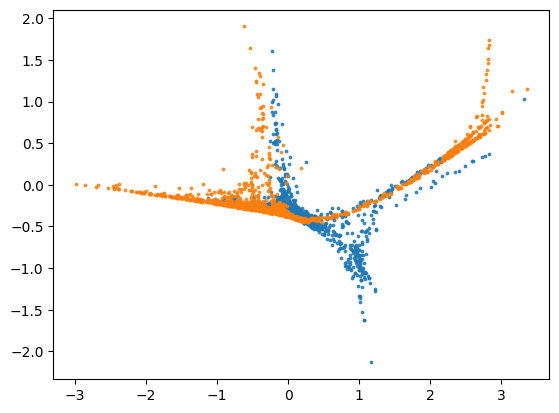

In [26]:
plt.scatter(trajectories[0][:,0], trajectories[0][:,2], s=3, alpha=0.8)
plt.scatter(trajectories[-1][:,0], trajectories[-1][:,2], s=3, alpha=0.8)

In [ ]:
np.save("results/MIOFlow/klein_subset_DM_EigenVectors_multiscaled/fate_bias_trajectory.npy", trajectories)

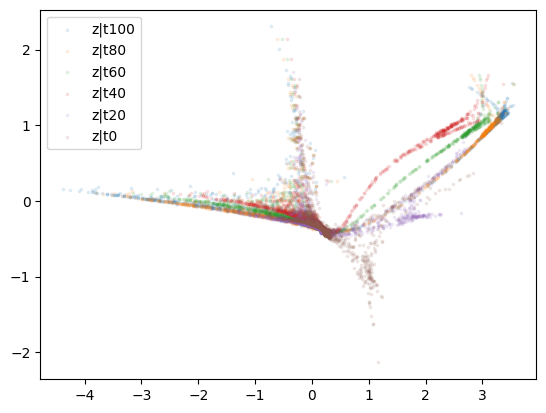

In [30]:
bw_traj = np.load("logs/TrajectoryNet/Weinreb_DM_whiten/backward_trajectories.npy")

%matplotlib inline
plt.scatter(trajectories[-1][:,0], trajectories[-1][:,2], s=3, alpha=0.1)
plt.scatter(trajectories[80][:,0], trajectories[80][:,2], s=3, alpha=0.1)
plt.scatter(trajectories[60][:,0], trajectories[80][:,2], s=3, alpha=0.1)
plt.scatter(trajectories[40][:,0], trajectories[80][:,2], s=3, alpha=0.1)
plt.scatter(trajectories[20][:,0], trajectories[20][:,2], s=3, alpha=0.1)
plt.scatter(trajectories[0][:,0], trajectories[0][:,2], s=3, alpha=0.1)
plt.legend(['z|t100', 'z|t80','z|t60', 'z|t40', 'z|t20', 'z|t0'])
plt.show()